In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Data Analyst Projects/06_Marketing_Campaign_Performance_Analytics/marketing_campaign_dataset.csv")

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (200000, 16)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  str    
 2   Campaign_Type     200000 non-null  str    
 3   Target_Audience   200000 non-null  str    
 4   Duration          200000 non-null  str    
 5   Channel_Used      200000 non-null  str    
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  str    
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  str    
 10  Language          200000 non-null  str    
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  str    
 15  Date              200000 non-null  str    
dtypes: float64(2), int64(4), str(10

In [6]:
missing_values = df.isnull().sum()
print("Missing Values Per Column:")
print(missing_values)

Missing Values Per Column:
Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64


In [43]:
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully!")

Total Duplicate Rows: 0


In [15]:
# Clean Acquisition_Cost Column
df['Acquisition_Cost'] = df['Acquisition_Cost'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

df['Acquisition_Cost'].describe()


count    200000.000000
mean      12504.393040
std        4337.664545
min        5000.000000
25%        8739.750000
50%       12496.500000
75%       16264.000000
max       20000.000000
Name: Acquisition_Cost, dtype: float64

In [16]:
# Clean Duration & Convert Date Column
df['Duration_Days'] = df['Duration'].astype(str).str.extract(r'(\d+)').astype(int)
df.drop(columns=['Duration'], inplace=True)

df['Date'] = pd.to_datetime(df['Date'])

df[['Date', 'Duration_Days']].head()

,Date,Duration_Days
0,2021-01-01,30
1,2021-01-02,60
2,2021-01-03,30
3,2021-01-04,60
4,2021-01-05,15


In [21]:
# 1. Click-Through Rate (CTR %)
df['CTR_%'] = np.where(df['Impressions'] > 0, (df['Clicks'] / df['Impressions']) * 100, 0).round(2)

# 2. Cost Per Click (CPC)
df['CPC'] = np.where(df['Clicks'] > 0, df['Acquisition_Cost'] / df['Clicks'], 0).round(2)

# 3. Revenue Generated = Acquisition_Cost * (1 + ROI)
df['Calculated_Revenue'] = (df['Acquisition_Cost'] * (1 + df['ROI'])).round(2)

# 4. Net Profit
df['Net_Profit'] = (df['Calculated_Revenue'] - df['Acquisition_Cost']).round(2)

df[['Acquisition_Cost', 'ROI', 'CTR_%', 'CPC', 'Calculated_Revenue', 'Net_Profit']].head()

,Acquisition_Cost,ROI,CTR_%,CPC,Calculated_Revenue,Net_Profit
0,16174.0,6.29,26.33,31.96,117908.46,101734.46
1,11566.0,5.61,1.54,99.71,76451.26,64885.26
2,10200.0,7.18,7.59,17.47,83436.00,73236.00
3,12724.0,5.55,11.92,58.64,83342.20,70618.20
4,16452.0,6.50,9.02,43.41,123390.00,106938.00


In [22]:
# Sub-columns and Types check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Campaign_ID         200000 non-null  int64         
 1   Company             200000 non-null  str           
 2   Campaign_Type       200000 non-null  str           
 3   Target_Audience     200000 non-null  str           
 4   Channel_Used        200000 non-null  str           
 5   Conversion_Rate     200000 non-null  float64       
 6   Acquisition_Cost    200000 non-null  float64       
 7   ROI                 200000 non-null  float64       
 8   Location            200000 non-null  str           
 9   Language            200000 non-null  str           
 10  Clicks              200000 non-null  int64         
 11  Impressions         200000 non-null  int64         
 12  Engagement_Score    200000 non-null  int64         
 13  Customer_Segment    200000 non-null  str

In [23]:
# Statistical summary of core metrics
df[['Acquisition_Cost', 'ROI', 'CTR_%', 'CPC', 'Calculated_Revenue', 'Net_Profit']].describe().round(2)

,Acquisition_Cost,ROI,CTR_%,CPC,Calculated_Revenue,Net_Profit
count,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00
mean,12504.39,5.00,14.04,32.01,75091.34,62586.94
std,4337.66,1.73,13.09,26.93,34799.24,31667.57
min,5000.00,2.00,1.01,5.02,15071.07,10064.07
25%,8739.75,3.50,5.86,15.09,47728.08,37809.71
50%,12496.50,5.01,9.98,22.77,68814.84,56193.52
75%,16264.00,6.51,16.97,38.60,98146.36,83274.24
max,20000.00,8.00,99.20,199.96,179438.36,159456.36


In [24]:
# Category Distribution Analysis
print("--- CAMPAIGN TYPES COUNT ---")
print(df['Campaign_Type'].value_counts())

print("\n--- CHANNELS USED COUNT ---")
print(df['Channel_Used'].value_counts())

print("\n--- TARGET AUDIENCE COUNT ---")
print(df['Target_Audience'].value_counts())

--- CAMPAIGN TYPES COUNT ---
Campaign_Type
Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: count, dtype: int64

--- CHANNELS USED COUNT ---
Channel_Used
Email         33599
Google Ads    33438
YouTube       33392
Instagram     33392
Website       33360
Facebook      32819
Name: count, dtype: int64

--- TARGET AUDIENCE COUNT ---
Target_Audience
Men 18-24      40258
Men 25-34      40023
All Ages       40019
Women 25-34    40013
Women 35-44    39687
Name: count, dtype: int64


In [39]:
# Formatted Business Summary
channel_summary = (
    df.groupby("Channel_Used")
    .agg(
        Total_Campaigns=("Campaign_ID", "count"),
        Spend_M=("Acquisition_Cost", lambda x: x.sum() / 1e6),
        Revenue_M=("Calculated_Revenue", lambda x: x.sum() / 1e6),
        Profit_M=("Net_Profit", lambda x: x.sum() / 1e6),
        Avg_ROI=("ROI", "mean"),
        Avg_CTR=("CTR_%", "mean"),
    )
    .sort_values(by="Revenue_M", ascending=False)
    .reset_index()
)

print(channel_summary.to_string(index=False))

Channel_Used  Total_Campaigns  Spend_M  Revenue_M  Profit_M  Avg_ROI  Avg_CTR
       Email            33599   420.87    2524.64   2103.77     5.00    14.05
  Google Ads            33438   418.91    2516.72   2097.81     5.00    13.92
     Website            33360   416.59    2504.15   2087.56     5.01    14.10
     YouTube            33392   416.78    2501.10   2084.33     4.99    14.12
   Instagram            33392   417.12    2497.10   2079.98     4.99    14.00
    Facebook            32819   410.60    2474.54   2063.95     5.02    14.05


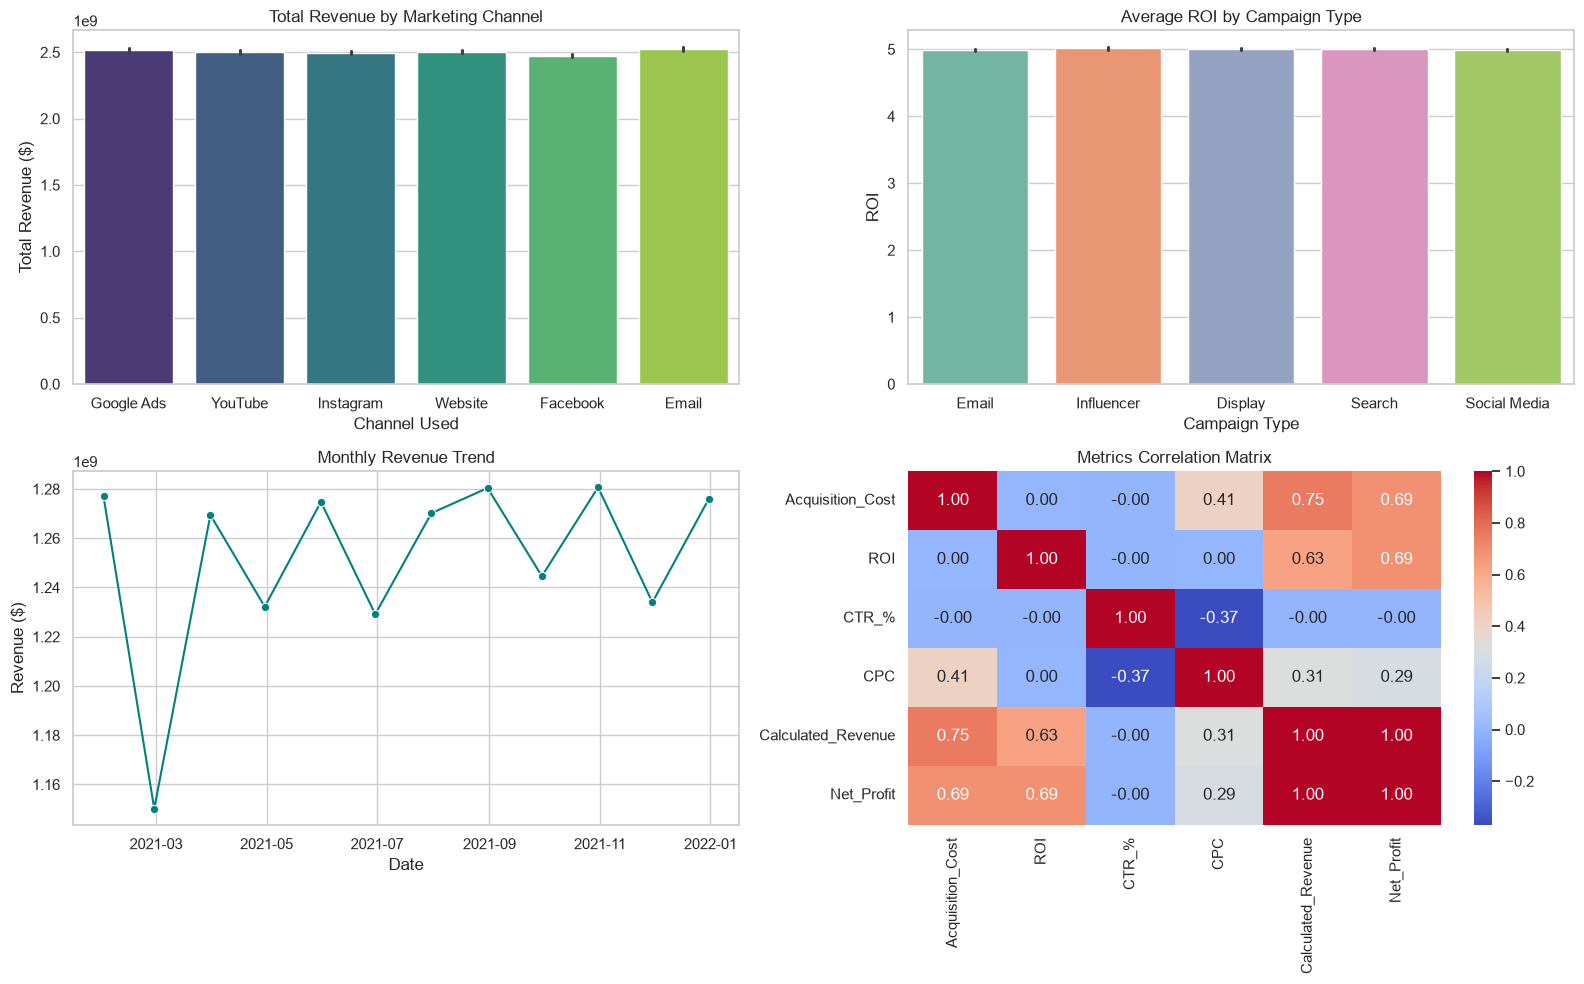

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# 1. Total Revenue by Marketing Channel
plt.subplot(2, 2, 1)
sns.barplot(
    data=df,
    x="Channel_Used",
    y="Calculated_Revenue",
    hue="Channel_Used",
    estimator=sum,
    palette="viridis",
    legend=False,
)
plt.title("Total Revenue by Marketing Channel")
plt.xlabel("Channel Used")
plt.ylabel("Total Revenue ($)")

# 2. Average ROI by Campaign Type
plt.subplot(2, 2, 2)
sns.barplot(
    data=df,
    x="Campaign_Type",
    y="ROI",
    hue="Campaign_Type",
    palette="Set2",
    legend=False,
)
plt.title("Average ROI by Campaign Type")
plt.xlabel("Campaign Type")
plt.ylabel("ROI")

# 3. Monthly Revenue Trend ('ME' updated offset for newer Pandas versions)
plt.subplot(2, 2, 3)
df_monthly = (
    df.resample("ME", on="Date")["Calculated_Revenue"].sum().reset_index()
)
sns.lineplot(
    data=df_monthly, x="Date", y="Calculated_Revenue", marker="o", color="teal"
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")

# 4. Metrics Correlation Heatmap
plt.subplot(2, 2, 4)
numeric_cols = [
    "Acquisition_Cost",
    "ROI",
    "CTR_%",
    "CPC",
    "Calculated_Revenue",
    "Net_Profit",
]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Metrics Correlation Matrix")

plt.tight_layout()
plt.show()

In [42]:
# Cleaned CSV Export
output_path = r"C:\Data Analyst Projects\06_Marketing_Campaign_Performance_Analytics\cleaned_marketing_data.csv"
df.to_csv(output_path, index=False)

print(f"Cleaned dataset successfully saved to: {output_path}")

Cleaned dataset successfully saved to: C:\Data Analyst Projects\06_Marketing_Campaign_Performance_Analytics\cleaned_marketing_data.csv
